In [1]:
# 1- importing libraries
# 2- loading and preprocessing the data 
# 3- defining the model architecture
# 4- defining the loss function and optimizer
# 5- training the model
# 6- evaluating the model
# 7- visualizing the results

In [2]:
# =========================
# PyTorch / Deep Learning
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# =========================
# Data manipulation
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt

# =========================
# Machine Learning utilities
# =========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# System / device setup
# =========================
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# If it prints "cuda:0", GPU is available.
# Otherwise, it is running on CPU.

cuda:0


In [3]:
# ======================
# Device
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# ======================
# Hyperparameters
# ======================
batch_size = 64
learning_rate = 1e-3
num_epochs = 10

In [5]:
# ======================
# MNIST Data
# ======================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [6]:
# ======================
# Model
# ======================
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 500)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(500, 100)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(100, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten

        x = self.fc1(x)
        x = self.relu1(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)

        x = self.fc3(x)
        return x   # NO softmax (important for CrossEntropyLoss)

model = Net().to(device)

In [7]:
# ======================
# Loss + Optimizer
# ======================
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [8]:
# ======================
# History
# ======================
loss_his_train = []
loss_his_test = []
acc_his_train = []
acc_his_test = []

# ======================
# Training Loop
# ======================
for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(x_batch)
        loss = loss_func(pred, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * y_batch.size(0)
        _, predicted = torch.max(pred, 1)
        train_correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss /= total
    train_acc = train_correct / total

    # -------- TEST --------
    model.eval()
    test_loss = 0
    test_correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(x_batch)
            loss = loss_func(pred, y_batch)

            test_loss += loss.item() * y_batch.size(0)
            _, predicted = torch.max(pred, 1)
            test_correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    test_loss /= total
    test_acc = test_correct / total

    # Save history
    loss_his_train.append(train_loss)
    loss_his_test.append(test_loss)
    acc_his_train.append(train_acc)
    acc_his_test.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/10] Train Loss: 0.2854, Train Acc: 0.9127 | Test Loss: 0.1287, Test Acc: 0.9575
Epoch [2/10] Train Loss: 0.1403, Train Acc: 0.9577 | Test Loss: 0.0906, Test Acc: 0.9731
Epoch [3/10] Train Loss: 0.1114, Train Acc: 0.9667 | Test Loss: 0.0814, Test Acc: 0.9747
Epoch [4/10] Train Loss: 0.0938, Train Acc: 0.9710 | Test Loss: 0.0777, Test Acc: 0.9765
Epoch [5/10] Train Loss: 0.0831, Train Acc: 0.9744 | Test Loss: 0.0703, Test Acc: 0.9804
Epoch [6/10] Train Loss: 0.0727, Train Acc: 0.9775 | Test Loss: 0.0805, Test Acc: 0.9769
Epoch [7/10] Train Loss: 0.0692, Train Acc: 0.9783 | Test Loss: 0.0796, Test Acc: 0.9774
Epoch [8/10] Train Loss: 0.0650, Train Acc: 0.9800 | Test Loss: 0.0777, Test Acc: 0.9792
Epoch [9/10] Train Loss: 0.0602, Train Acc: 0.9810 | Test Loss: 0.0656, Test Acc: 0.9795
Epoch [10/10] Train Loss: 0.0562, Train Acc: 0.9824 | Test Loss: 0.0793, Test Acc: 0.9786


In [9]:
# 1- draw accuray and loss chart
# 2- claculate accuray
# 3- confusion matrix
# 3- disply some sammple image
# 8. Save/load model
# 9. Predict on new images
# 10. Grad-CAM visualization

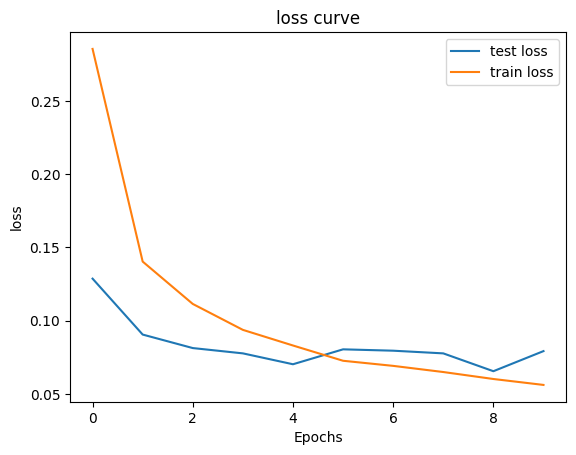

In [10]:
plt.plot(loss_his_test, label="test loss")
plt.plot(loss_his_train, label="train loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.title("loss curve")
plt.legend()
plt.show()

In [11]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())    

In [12]:
def classification_report_and_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    print("Classification Report:")
    print(classification_report(all_labels, all_preds))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

In [13]:
print("train_classification_report_and_confusion_matrix")
classification_report_and_confusion_matrix(model, train_loader)
print("test_classification_report_and_confusion_matrix")
classification_report_and_confusion_matrix(model, test_loader)

train_classification_report_and_confusion_matrix
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5923
           1       0.99      1.00      0.99      6742
           2       0.99      1.00      0.99      5958
           3       0.99      0.98      0.99      6131
           4       0.99      0.99      0.99      5842
           5       1.00      0.97      0.99      5421
           6       1.00      0.99      1.00      5918
           7       0.98      1.00      0.99      6265
           8       0.99      0.99      0.99      5851
           9       0.98      0.99      0.99      5949

    accuracy                           0.99     60000
   macro avg       0.99      0.99      0.99     60000
weighted avg       0.99      0.99      0.99     60000

Confusion Matrix:
[[5879    1    6    1    6    0   15    3    8    4]
 [   0 6727    2    0    1    0    0   10    2    0]
 [   0    3 5936    1    5    0    0   11    

In [14]:
import random
import torch
import matplotlib.pyplot as plt

def display_sample_images(data_loader, num_samples=5, cols=5):
    model.eval()
    all_samples = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)

            for i in range(x_batch.size(0)):
                img = x_batch[i].cpu().numpy().squeeze()
                label = y_batch[i].item()
                pred_label = predicted[i].item()

                all_samples.append((img, label, pred_label))

    # ---- RANDOM SELECTION ----
    samples = random.sample(all_samples, k=min(num_samples, len(all_samples)))

    # ---- Plot grid ----
    rows = (num_samples + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))

    for idx, (img, label, pred_label) in enumerate(samples):
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"T:{label} P:{pred_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

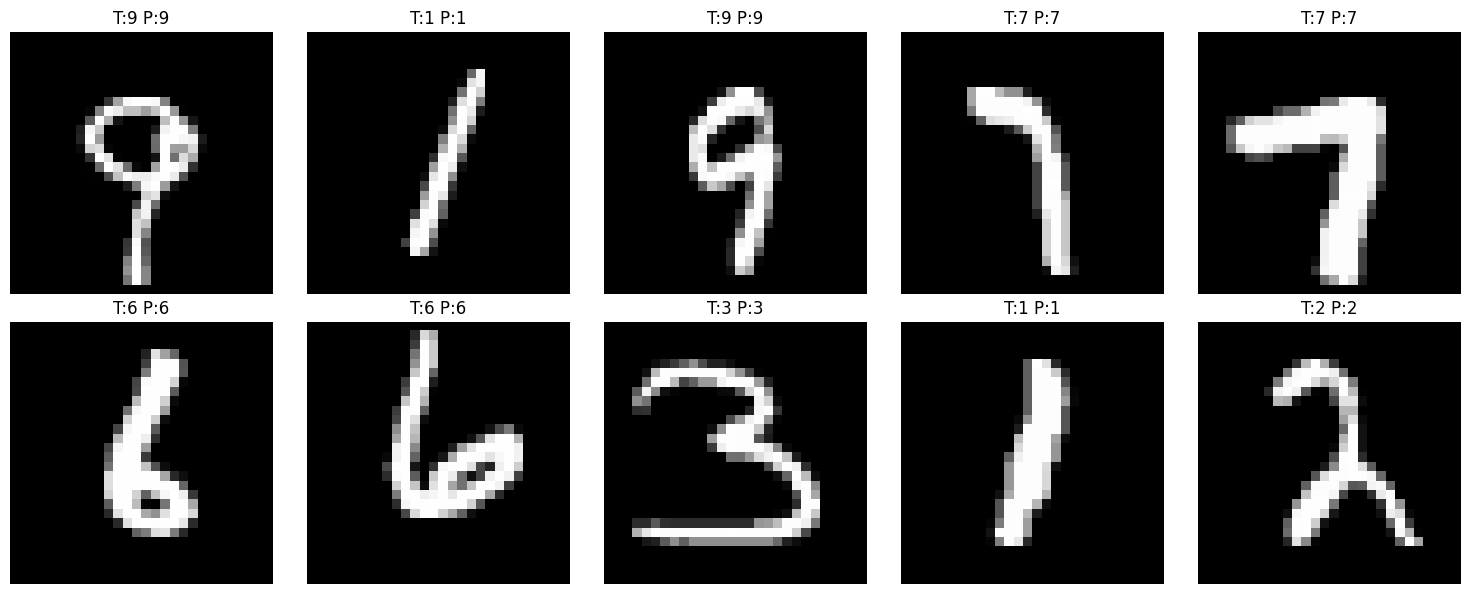

In [15]:
display_sample_images(test_loader, num_samples=10)